# Regressão Linear

Dados originais:
    ano  trimestre tipo_carne  producao_cabecas_anual_mi  abate_cabecas  \
0  2014          1     bovino                     212.34          8.366   
1  2014          2     bovino                     212.34          8.516   
2  2014          3     bovino                     212.34          8.456   
3  2014          4     bovino                     212.34          8.525   
4  2014          1      suino                      37.93          8.686   

   peso_carcaca_ton  exportacao_usd  media_cambio_usdbrl  custo_milho_rs  \
0             1.951           1.345                 2.34           22.57   
1             2.006           1.384                 2.22           23.59   
2             2.036           1.547                 2.28           19.97   
3             2.058           1.519                 2.59           21.46   
4             0.747           0.260                 2.34           22.57   

   custo_soja_rs  preco_medio_ton_usd  
0          62.01                4.4

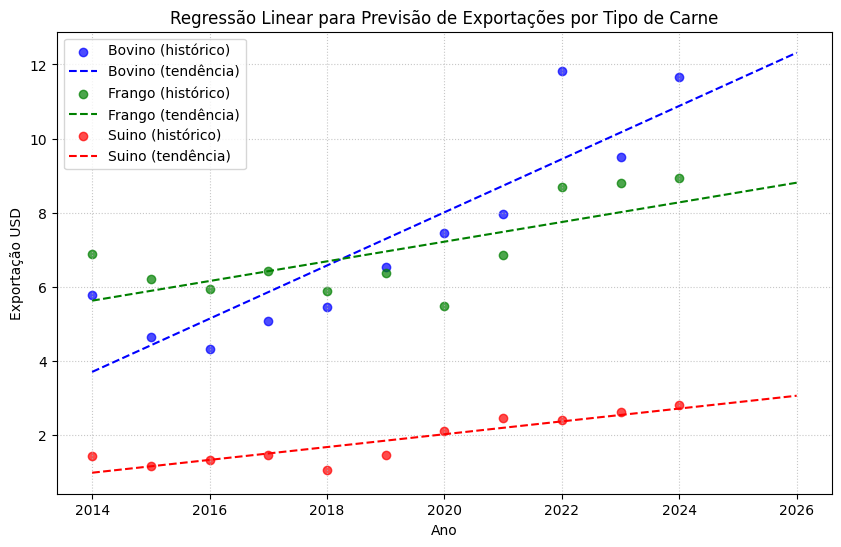

In [7]:
# -*- coding: utf-8 -*-
"""Regressão Linear simples usando ano como variável preditora de exportacao_usd."""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Carregar dados e agregar por ano para cada tipo de carne
data = pd.read_csv("/content/carne-brasileira-exportada.csv", encoding='utf-8', sep=',')
print("Dados originais:")
print(data.head(), "\n")

# Ajusta nomes de colunas e agrega por ano
agg = (
    data[['ano', 'tipo_carne', 'exportacao_usd']]
    .dropna()
    .groupby(['ano', 'tipo_carne'], as_index=False)
    .sum()
)

# Cria tabela anual ampla com uma coluna para cada tipo de carne
df = agg.pivot(index='ano', columns='tipo_carne', values='exportacao_usd').reset_index()
df.columns.name = None
print("\nDados agregados por ano:")
print(df)

start_year = int(df['ano'].min())
df['t'] = df['ano'] - start_year

produtos = [col for col in df.columns if col not in ['ano', 't']]
modelos = {}

print("=" * 60)
print("REGRESSÃO LINEAR SIMPLES: Valor exportado = a * t + b")
print(f"t = Ano - {start_year}")
print("=" * 60)

for prod in produtos:
    X = df[['t']].values
    y = df[prod].values

    modelo = LinearRegression()
    modelo.fit(X, y)
    modelos[prod] = modelo

    a = float(modelo.coef_[0])
    b = float(modelo.intercept_)
    y_pred = modelo.predict(X)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y - y_pred) / (np.where(y == 0, 1e-8, y)))) * 100
    r2 = modelo.score(X, y)

    tscv = TimeSeriesSplit(n_splits=min(5, len(df) - 1))
    cv_scores = cross_val_score(modelo, X, y, cv=tscv, scoring='neg_mean_squared_error')
    cv_mse = -cv_scores.mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mape = np.mean(np.sqrt(np.abs(cv_scores))) if len(cv_scores) > 0 else np.nan

    print(f"\nProduto: {prod.capitalize()}")
    print(f"  Equação: Valor = {a:.4f} * t + {b:.4f}")
    print(f"  R² = {r2:.4f}")
    print(f"  MSE = {mse:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  MAPE = {mape:.2f}%")
    print(f"  Validação cruzada (MSE médio) = {cv_mse:.4f}")
    print(f"  Validação cruzada (RMSE médio) = {cv_rmse:.4f}")
    print(f"  Validação cruzada (MAPE implícito) = {cv_mape:.4f}")

    t_futuro = np.array([[2025 - start_year], [2026 - start_year]])
    pred = modelo.predict(t_futuro)
    print(f"  Previsão 2025 (t={2025 - start_year}): {pred[0]:.2f}")
    print(f"  Previsão 2026 (t={2026 - start_year}): {pred[1]:.2f}")

plt.figure(figsize=(10, 6))
cores = {prod: color for prod, color in zip(produtos, ['blue', 'green', 'red', 'orange', 'purple'])}
for prod in produtos:
    plt.scatter(df['ano'], df[prod], color=cores.get(prod, 'black'), alpha=0.7, label=f'{prod.capitalize()} (histórico)')
    modelo = modelos[prod]
    t_vals = np.linspace(df['t'].min(), 2026 - start_year, 100).reshape(-1, 1)
    y_pred = modelo.predict(t_vals)
    anos_reta = t_vals.flatten() + start_year
    plt.plot(anos_reta, y_pred, color=cores.get(prod, 'black'), linestyle='--', label=f'{prod.capitalize()} (tendência)')

plt.xlabel('Ano')
plt.ylabel('Exportação USD')
plt.title('Regressão Linear para Previsão de Exportações por Tipo de Carne')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()
